Raw feature count: 978
Number of shared features: 978
After removing low variance features: 978
After removing highly correlated features: 320


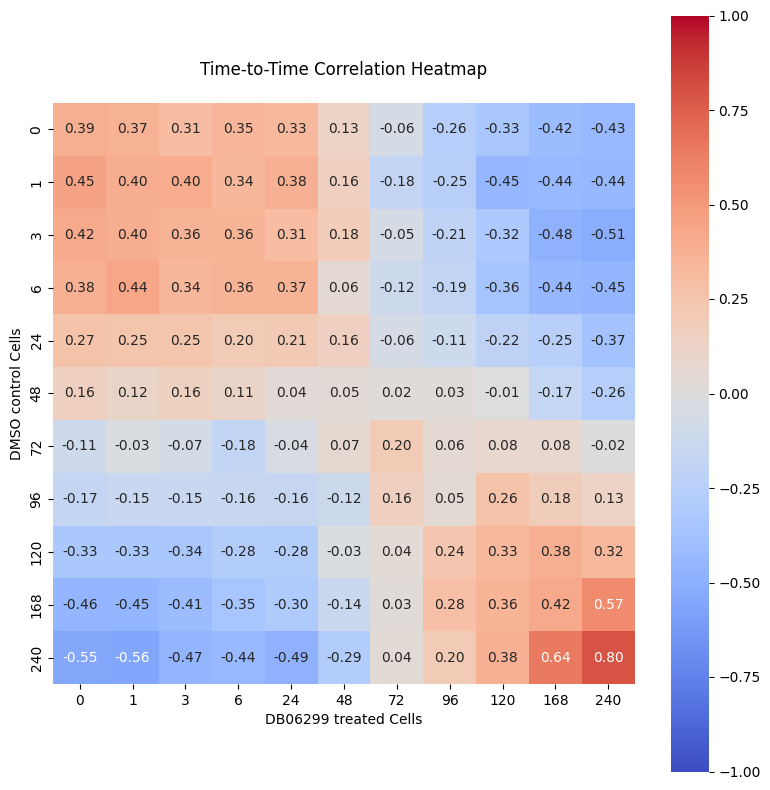


相关系数矩阵:
          0         1         3         6         24        48        72   \
0    0.388881  0.369210  0.307784  0.351157  0.325946  0.131530 -0.060759   
1    0.448031  0.395799  0.404129  0.337921  0.381163  0.160954 -0.176621   
3    0.418029  0.395771  0.361670  0.358351  0.309808  0.180830 -0.054847   
6    0.379034  0.435831  0.342974  0.364766  0.365180  0.058699 -0.118028   
24   0.265398  0.246009  0.249239  0.195878  0.211944  0.160145 -0.055690   
48   0.157498  0.115340  0.155515  0.112158  0.036272  0.046226  0.016716   
72  -0.106764 -0.029478 -0.074704 -0.184433 -0.036279  0.067483  0.199485   
96  -0.174352 -0.145218 -0.146678 -0.155241 -0.162762 -0.123402  0.159040   
120 -0.325800 -0.325024 -0.339306 -0.278713 -0.279703 -0.030033  0.040061   
168 -0.458648 -0.453806 -0.414935 -0.346416 -0.300242 -0.137618  0.028218   
240 -0.554279 -0.558030 -0.467824 -0.435915 -0.491220 -0.287984  0.040482   

          96        120       168       240  
0   -0.258827 -0.328

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
plt.style.use('default')

# --- Define parameters ---
rows_per_condition = 200
n_original_rows = 2200
n_cols = 978
n_conditions = n_original_rows // rows_per_condition

# --- step 1: Load the data ---
df1_original = pd.read_csv('../data/TimeSensitivity/DMSOctrl_fibrosis_DEGs.csv')
df1_original.drop(columns=['cell_iname','pert_id'], inplace=True)


df2_original = pd.read_csv('../data/TimeSensitivity/DB00641trt_fibrosis_DEGs.csv')
df2_original.drop(columns=['cell_iname','pert_id'], inplace=True)


# --- step 2: Data grouping and averaging. ---
group_key = df1_original.index // rows_per_condition
# group_key = 'pert_itime'
df1_avg = df1_original.groupby(group_key).mean()
df2_avg = df2_original.groupby(group_key).mean()
# print(df1_avg)

# --- step 3: Feature engineering and feature selection. ---
def feature_engineering(df1, df2):
    common_features = df1.columns.intersection(df2.columns)
    df1 = df1[common_features]
    df2 = df2[common_features]
    
    # 1. Standardization
    scaler = StandardScaler()
    df1_scaled = pd.DataFrame(scaler.fit_transform(df1), columns=df1.columns)
    df2_scaled = pd.DataFrame(scaler.fit_transform(df2), columns=df2.columns)
    
    # 2. Eliminating low-variance features.
    selector = VarianceThreshold(threshold=0.1)
    combined_data = pd.concat([df1_scaled, df2_scaled])
    selector.fit(combined_data)
    
    selected_features = df1.columns[selector.get_support()]
    df1_var = pd.DataFrame(selector.transform(df1_scaled), columns=selected_features)
    df2_var = pd.DataFrame(selector.transform(df2_scaled), columns=selected_features)
    
    # 3. Eliminate highly correlated features.
    combined_corr = pd.concat([df1_var, df2_var]).corr().abs()
    upper = combined_corr.where(np.triu(np.ones(combined_corr.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]#0.95
    
    df1_final = df1_var.drop(columns=to_drop)
    df2_final = df2_var.drop(columns=to_drop)
    
    print(f"Raw feature count: {df1.shape[1]}")
    print(f"Number of shared features: {len(common_features)}")
    print(f"After removing low variance features: {df1_var.shape[1]}")
    print(f"After removing highly correlated features: {df1_final.shape[1]}")
    
    return df1_final, df2_final

# Feature Engineering
df1_avg_engineered, df2_avg_engineered = feature_engineering(df1_avg, df2_avg)

# --- step 4: Calculate the correlation matrix of an 11x11 matrix. ---
# Calculate the correlation coefficient between each pair of cells.
corr_matrix = np.zeros((11, 11))

for i in range(11):
    for j in range(11):
        corr = np.corrcoef(df1_avg_engineered.iloc[i], df2_avg_engineered.iloc[j])[0,1]
        corr_matrix[i,j] = corr

corr_df = pd.DataFrame(
    corr_matrix,
    index=[0, 1, 3, 6, 24, 48, 72, 96, 120, 168, 240],
    columns=[0, 1, 3, 6, 24, 48, 72, 96, 120, 168, 240]
)#[f'Time_{i+1}' for i in range(11)]

# --- step 5: Draw a heatmap. ---
plt.figure(figsize=(8, 8))

sns.heatmap(
    corr_df,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    xticklabels=True,   
    yticklabels=True    
)

plt.title('Time-to-Time Correlation Heatmap', pad=20)
plt.xlabel('DB06299 treated Cells')
plt.ylabel('DMSO control Cells')

plt.tight_layout()
plt.savefig(".../figures/DB00641trt_fibrosis.svg",format="svg", bbox_inches='tight') # Save graphic as SVG.
plt.show()

# 打印相关系数矩阵
print("\nCorrelation matrix:")
print(corr_df)
